# Predicting Customer Response to a Direct Marketing Campaign
### A Machine Learning Approach to Targeted Retail Marketing — Machine Learning (X0827)

This notebook reproduces, on the `marketing_campaign.csv` file, **every analysis and all 11 figures** given in the group-assignment report:

| Section | Content | Report figure / table |
|---|---|---|
| 1 | Setup & data loading | Metadata |
| 2 | Data pre-processing & cleaning (missing values, constant columns, label clean-up, outliers) | §3 |
| 3 | Feature engineering (10 engineered features) & descriptive statistics | §2, §3.5 |
| 4 | Exploratory Data Analysis | **Fig 1 – Fig 5** |
| 5 | Problem formulation, train/test split, scaling | §5 |
| 6 | Seven-model comparison, ROC curves | **Fig 6, Fig 7** |
| 7 | Hyper-parameter tuning (GridSearchCV) & threshold optimisation | §6.2, §6.3 |
| 8 | Final model, confusion matrix | **Fig 8** |
| 9 | Feature importance & logistic-regression odds ratios | **Fig 9** |
| 10 | K-Means customer segmentation | **Fig 10, Fig 11** |
| 11 | Deployable scoring system, priority bands, decile lift | §9 |
| 12 | Summary of results | §11 |

> **Note:** exact numbers can differ slightly from the printed report depending on random seeds and library versions. All seeds are fixed (`RANDOM_STATE = 42`) so the notebook is fully reproducible.

## 1. Setup and Data Loading

**Libraries used** (as listed in §10.2 of the report): `pandas` (data handling & feature engineering), `NumPy` (numerics), `Matplotlib` & `Seaborn` (plots), `scikit-learn` (scaling, models, tuning, metrics, K-Means, PCA).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             silhouette_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# ---- Path to the data file --------------------------------------------------
# Put marketing_campaign.csv in the same folder as this notebook (or edit the path).
# In Google Colab: upload the file via the Files panel, or run
#     from google.colab import files; files.upload()
CANDIDATE_PATHS = ["marketing_campaign.csv", "/content/marketing_campaign.csv",
                   "/mnt/user-data/uploads/marketing_campaign.csv"]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
assert DATA_PATH is not None, "marketing_campaign.csv not found - update DATA_PATH"

# The file is TAB-separated even though it has a .csv extension (see report metadata)
raw = pd.read_csv(DATA_PATH, sep="\t")
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,"58,138.0000",0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,"46,344.0000",1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,"71,613.0000",0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,"26,646.0000",1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,"58,293.0000",1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
# Target variable balance in the raw data
cnt = raw["Response"].value_counts().sort_index()
print(pd.DataFrame({"count": cnt, "share_%": (cnt / cnt.sum() * 100).round(2)}))

          count  share_%
Response                
0          1906  85.0900
1           334  14.9100


## 2. Data Pre-processing and Cleaning (Report §3)

Four data-quality issues are treated: **(3.1)** missing values, **(3.2)** constant/redundant columns, **(3.3)** inconsistent categorical labels, **(3.4)** outliers.

In [5]:
df = raw.copy()

# ---- 3.1 Missing values ------------------------------------------------------
miss = df.isna().sum()
print("Missing values per column:")
print(miss[miss > 0].to_frame("missing").assign(pct=lambda d: (d["missing"] / len(df) * 100).round(2)))

# Income is right-skewed -> median imputation (mean would be pulled up by high earners)
income_median = df["Income"].median()
df["Income"] = df["Income"].fillna(income_median)
print(f"\nIncome imputed with median = {income_median:,.1f}   | remaining NaNs: {df.isna().sum().sum()}")

Missing values per column:
        missing    pct
Income       24 1.0700

Income imputed with median = 51,381.5   | remaining NaNs: 0


In [6]:
# ---- 3.2 Constant / redundant columns -----------------------------------------
nun = df.nunique()
constant_cols = nun[nun == 1].index.tolist()
print("Zero-variance columns:", constant_cols)
print(df[constant_cols].iloc[0].to_dict())
df = df.drop(columns=constant_cols)          # Z_CostContact, Z_Revenue
print("Shape after dropping:", df.shape)

Zero-variance columns: ['Z_CostContact', 'Z_Revenue']
{'Z_CostContact': 3, 'Z_Revenue': 11}
Shape after dropping: (2240, 27)


In [7]:
# ---- 3.3 Inconsistent categorical labels ----------------------------------------
print("Marital_Status BEFORE:")
print(df["Marital_Status"].value_counts())

# 'Absurd', 'YOLO' (noise) and 'Alone' (== Single) are consolidated into 'Single'
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})

print("\nMarital_Status AFTER:")
print(df["Marital_Status"].value_counts())

Marital_Status BEFORE:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital_Status AFTER:
Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [8]:
# ---- 3.4 Outlier treatment ------------------------------------------------------
# (a) Implausible birth years (< 1900  ->  age > 114) are data-entry errors: remove the rows
bad = df[df["Year_Birth"] < 1900]
print("Rows with Year_Birth < 1900:", len(bad))
display(bad[["ID", "Year_Birth", "Education", "Marital_Status", "Income"]])
df = df[df["Year_Birth"] >= 1900].copy()

# (b) Income: winsorise at the 99th percentile (retain every customer)
p99 = df["Income"].quantile(0.99)
n_capped = int((df["Income"] > p99).sum())
df["Income"] = df["Income"].clip(upper=p99)
print(f"\nIncome 99th percentile = {p99:,.0f}  -> {n_capped} values winsorised")
print("Working dataset shape:", df.shape)

Rows with Year_Birth < 1900: 2

Income 99th percentile = 94,439  -> 23 values winsorised
Working dataset shape: (2238, 27)


,ID,Year_Birth,Education,Marital_Status,Income
239,11004,1893,2n Cycle,Single,"60,182.0000"
339,1150,1899,PhD,Together,"83,532.0000"


## 3. Feature Engineering (Report §2) and Descriptive Statistics (§3.5)

Ten engineered features are derived: `Age`, `Customer_Tenure_Days`, `Total_Spend`, `Total_Purchases`, `Avg_Order_Value`, `Children`, `Has_Children`, `Total_Prev_Accepted`, `Living_With_Partner`, `Education_Level`.

In [9]:
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

df["Age"]                  = 2014 - df["Year_Birth"]
df["Customer_Tenure_Days"] = (pd.Timestamp("2014-12-31") - df["Dt_Customer"]).dt.days
df["Total_Spend"]          = df[mnt_cols].sum(axis=1)
df["Total_Purchases"]      = df[["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum(axis=1)
df["Avg_Order_Value"]      = (df["Total_Spend"] / df["Total_Purchases"].replace(0, np.nan)).fillna(0)
df["Children"]             = df["Kidhome"] + df["Teenhome"]
df["Has_Children"]         = (df["Children"] > 0).astype(int)
df["Total_Prev_Accepted"]  = df[cmp_cols].sum(axis=1)
df["Living_With_Partner"]  = df["Marital_Status"].isin(["Married", "Together"]).astype(int)
edu_order = {"Basic": 0, "2n Cycle": 1, "Graduation": 2, "Master": 3, "PhD": 4}
df["Education_Level"]      = df["Education"].map(edu_order)

engineered = ["Age", "Customer_Tenure_Days", "Total_Spend", "Total_Purchases", "Avg_Order_Value",
              "Children", "Has_Children", "Total_Prev_Accepted", "Living_With_Partner", "Education_Level"]
print("Working dataset:", df.shape)
df[engineered].head()

Working dataset: (2238, 37)


,Age,Customer_Tenure_Days,Total_Spend,Total_Purchases,Avg_Order_Value,Children,Has_Children,Total_Prev_Accepted,Living_With_Partner,Education_Level
0,57,848,1617,22,73.5000,0,0,0,0,2
1,60,298,27,4,6.7500,2,1,0,0,2
2,49,497,776,20,38.8000,0,0,0,1,2
3,30,324,53,6,8.8333,1,1,0,1,2
4,33,346,422,14,30.1429,1,1,0,1,4


In [10]:
# ---- 3.5 Descriptive statistics with skewness & kurtosis -----------------------
desc_vars = ["Age", "Income", "Recency", "Total_Spend", "Total_Purchases", "Customer_Tenure_Days", "NumWebVisitsMonth"]
desc = df[desc_vars].agg(["mean", "std", "min", "max", "skew", "kurt"]).T
desc.columns = ["Mean", "Std. Dev.", "Min", "Max", "Skewness", "Kurtosis"]
desc

,Mean,Std. Dev.,Min,Max,Skewness,Kurtosis
Age,45.1291,11.7896,18.0000,114.0000,0.1726,-0.3407
Income,"51,733.7320","20,646.1813","1,730.0000","94,439.4400",0.0032,-0.8659
Recency,49.1269,28.9688,0.0000,99.0000,-0.0034,-1.2022
Total_Spend,605.5018,601.8145,5.0000,"2,525.0000",0.8614,-0.3388
Total_Purchases,12.5407,7.2061,0.0000,32.0000,0.2969,-1.1186
Customer_Tenure_Days,538.7556,202.0995,185.0000,884.0000,-0.0162,-1.1947
NumWebVisitsMonth,5.3190,2.4259,0.0000,20.0000,0.2078,1.8268


**Interpretation.** `Total_Spend` is the most right-skewed variable (standard deviation almost equal to its mean → highly unequal customer value). `Income` and `Recency` are close to symmetric with negative kurtosis (flat, near-uniform shapes). `NumWebVisitsMonth` has positive kurtosis, i.e. a heavy tail of very frequent site visitors.

## 4. Exploratory Data Analysis (Report §4)
### 4.1 Distribution Analysis — Figure 1
Histograms with KDE overlay for Age, Income, Total Spend and Recency (shape, skew, need for transformation).

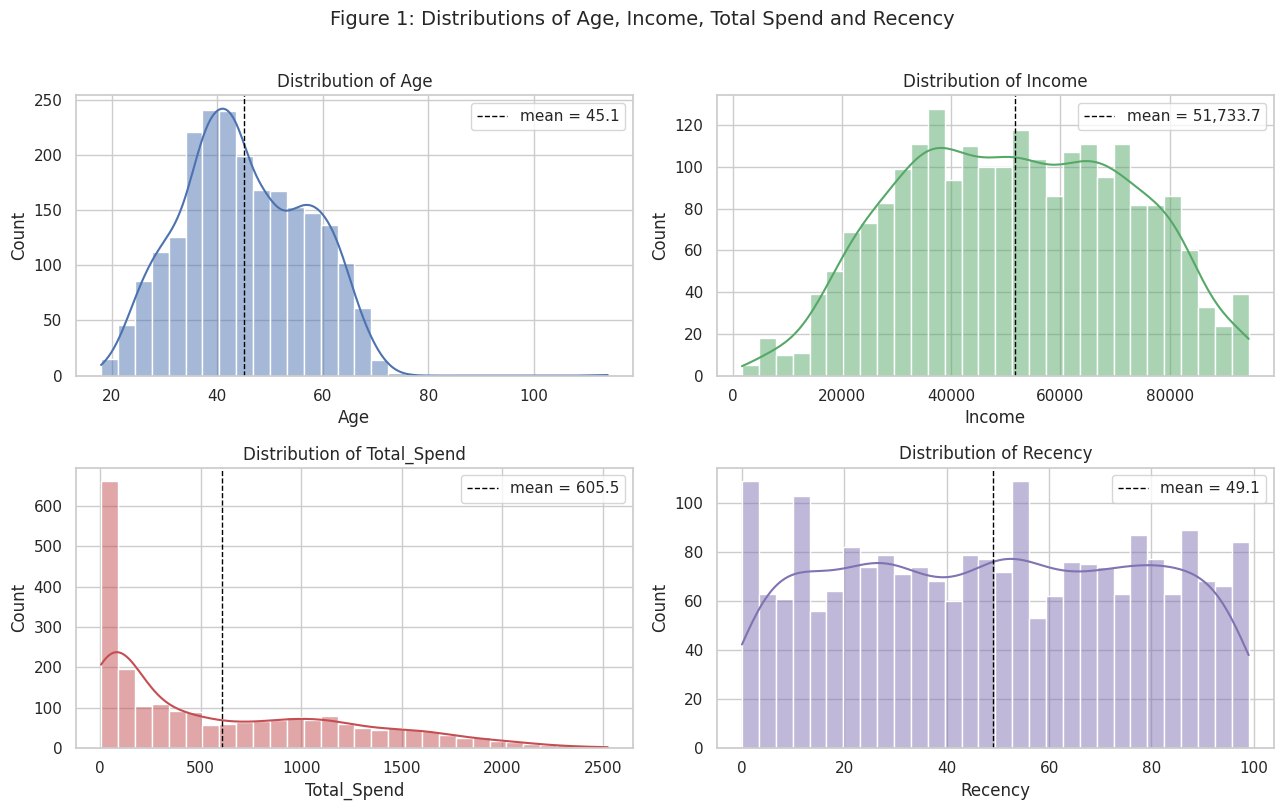

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, colr in zip(axes.ravel(), ["Age", "Income", "Total_Spend", "Recency"],
                         ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]):
    sns.histplot(df[col], kde=True, bins=30, color=colr, ax=ax)
    ax.axvline(df[col].mean(), color="black", ls="--", lw=1, label=f"mean = {df[col].mean():,.1f}")
    ax.set_title(f"Distribution of {col}")
    ax.legend()
fig.suptitle("Figure 1: Distributions of Age, Income, Total Spend and Recency", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Outlier Detection — Figure 2
Boxplots use the IQR rule (points beyond 1.5×IQR from the quartiles are flagged).

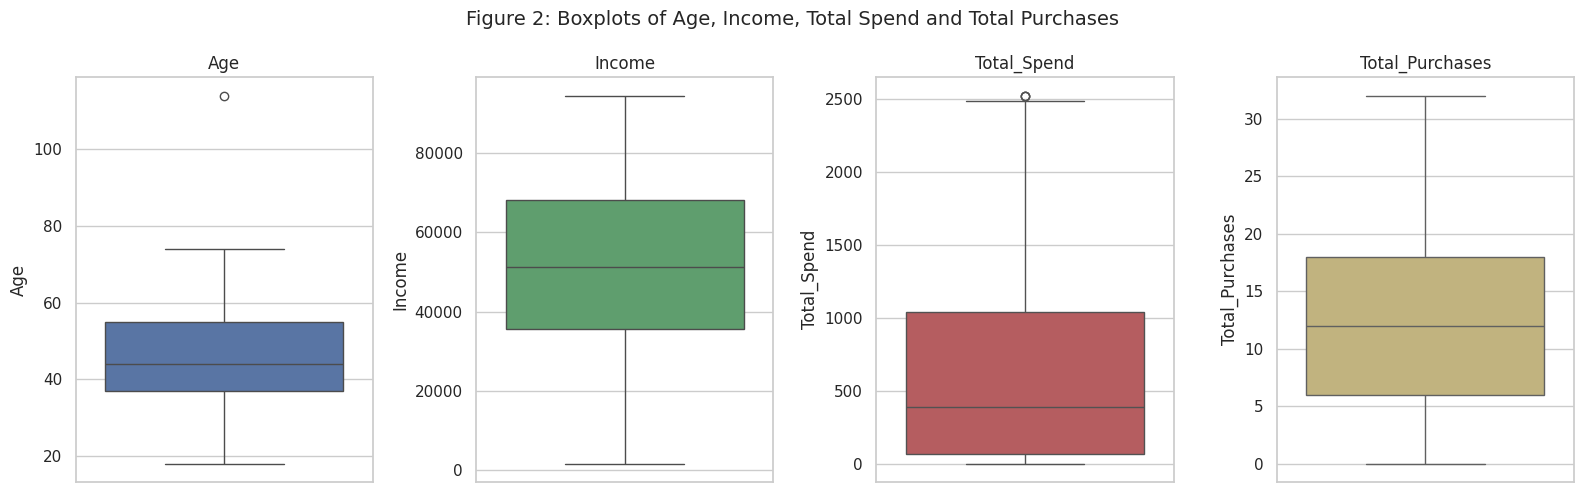

,Variable,IQR outliers,% of rows
0,Age,1,0.0400
1,Income,0,0.0000
2,Total_Spend,3,0.1300
3,Total_Purchases,0,0.0000


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col, colr in zip(axes, ["Age", "Income", "Total_Spend", "Total_Purchases"],
                         ["#4C72B0", "#55A868", "#C44E52", "#CCB974"]):
    sns.boxplot(y=df[col], color=colr, ax=ax)
    ax.set_title(col)
fig.suptitle("Figure 2: Boxplots of Age, Income, Total Spend and Total Purchases", fontsize=14)
plt.tight_layout()
plt.show()

# Quantify IQR outliers
rows = []
for col in ["Age", "Income", "Total_Spend", "Total_Purchases"]:
    q1, q3 = df[col].quantile([.25, .75]); iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    rows.append((col, n, round(n / len(df) * 100, 2)))
pd.DataFrame(rows, columns=["Variable", "IQR outliers", "% of rows"])

### 4.3 Class Imbalance in the Target — Figure 3
A model that predicts "no response" for everyone would already reach ≈ 85 % accuracy while being useless to the business → accuracy alone is inadequate; we use recall, precision, F1 and AUC-ROC, plus class weighting.

Majority-class ('always No') baseline accuracy = 0.8508


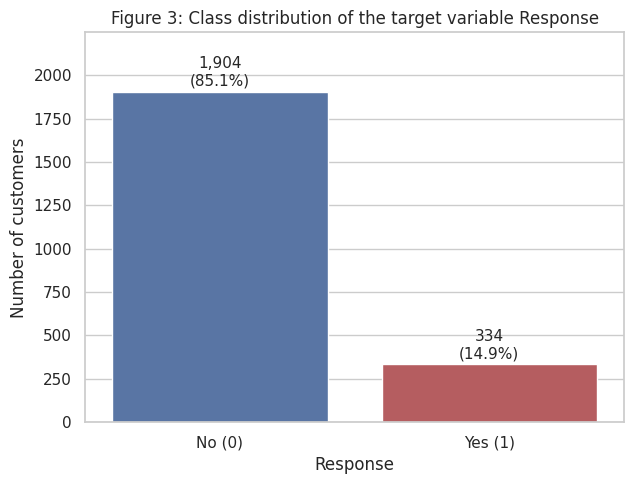

In [13]:
counts = df["Response"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.barplot(x=["No (0)", "Yes (1)"], y=counts.values, hue=["No (0)", "Yes (1)"],
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 35, f"{v:,}\n({v / counts.sum() * 100:.1f}%)", ha="center", fontsize=11)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_xlabel("Response"); ax.set_ylabel("Number of customers")
ax.set_title("Figure 3: Class distribution of the target variable Response")
plt.tight_layout(); plt.show()

print(f"Majority-class ('always No') baseline accuracy = {counts.max() / counts.sum():.4f}")

### 4.4 Response Rate across Categorical Drivers — Figure 4
Campaign response rate by **Education**, **Marital Status** and **number of prior campaigns accepted**.

Response rate (%) by prior campaigns accepted:
Total_Prev_Accepted
0    8.2000
1   31.2000
2   50.6000
3   79.5000
4   90.9000


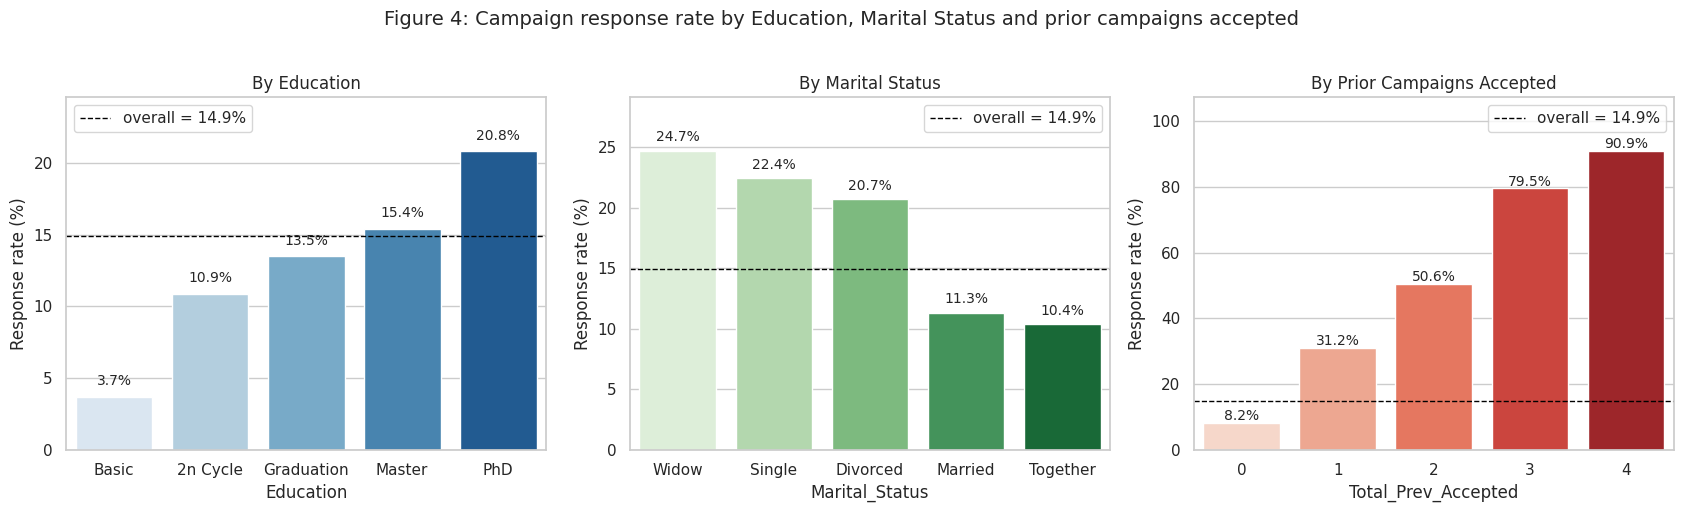

In [14]:
edu_plot_order = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

def rate_bar(ax, col, order, title, palette):
    rate = (df.groupby(col)["Response"].mean().reindex(order) * 100)
    sns.barplot(x=rate.index.astype(str), y=rate.values, hue=rate.index.astype(str),
                palette=palette, legend=False, ax=ax)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=10)
    ax.axhline(df["Response"].mean() * 100, color="black", ls="--", lw=1,
               label=f"overall = {df['Response'].mean() * 100:.1f}%")
    ax.set_ylabel("Response rate (%)"); ax.set_xlabel(col); ax.set_title(title); ax.legend()
    ax.set_ylim(0, max(rate.max() * 1.18, 20))
    return rate

r_edu = rate_bar(axes[0], "Education", edu_plot_order, "By Education", "Blues")
mar_order = df.groupby("Marital_Status")["Response"].mean().sort_values(ascending=False).index.tolist()
r_mar = rate_bar(axes[1], "Marital_Status", mar_order, "By Marital Status", "Greens")
prev_order = sorted(df["Total_Prev_Accepted"].unique())
r_prev = rate_bar(axes[2], "Total_Prev_Accepted", prev_order, "By Prior Campaigns Accepted", "Reds")

fig.suptitle("Figure 4: Campaign response rate by Education, Marital Status and prior campaigns accepted", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Response rate (%) by prior campaigns accepted:")
print(r_prev.round(1).to_string())

### 4.5 Correlation Analysis — Figure 5

Correlation with Response (sorted):


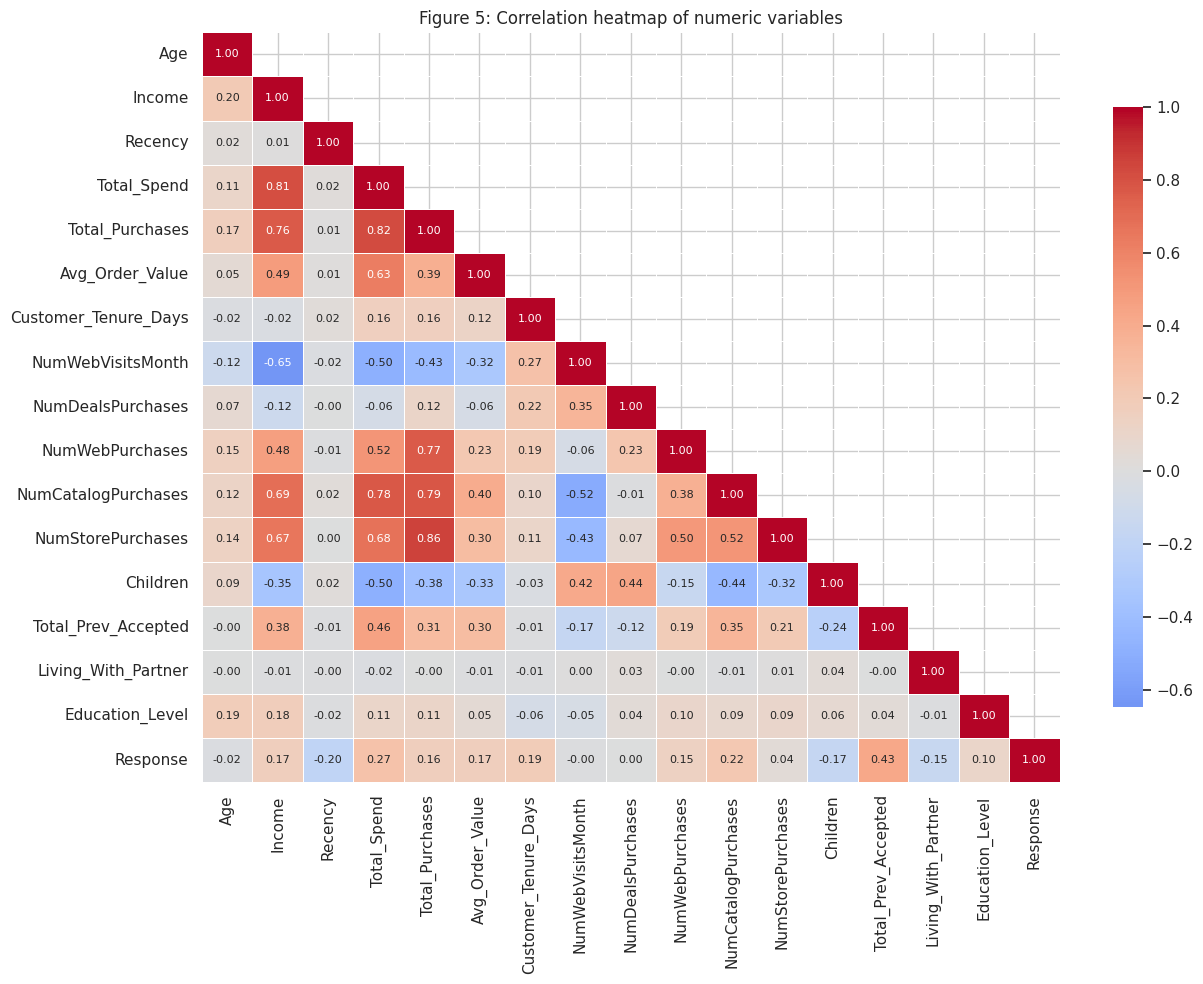

,r
Total_Prev_Accepted,0.4263
Total_Spend,0.2658
NumCatalogPurchases,0.2210
Customer_Tenure_Days,0.1942
Income,0.1688
Avg_Order_Value,0.1660
Total_Purchases,0.1646
NumWebPurchases,0.1486
Education_Level,0.0991
NumStorePurchases,0.0391


In [15]:
corr_vars = ["Age", "Income", "Recency", "Total_Spend", "Total_Purchases", "Avg_Order_Value",
             "Customer_Tenure_Days", "NumWebVisitsMonth", "NumDealsPurchases", "NumWebPurchases",
             "NumCatalogPurchases", "NumStorePurchases", "Children", "Total_Prev_Accepted",
             "Living_With_Partner", "Education_Level", "Response"]
corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Figure 5: Correlation heatmap of numeric variables")
plt.tight_layout(); plt.show()

print("Correlation with Response (sorted):")
corr["Response"].drop("Response").sort_values(ascending=False).to_frame("r")

## 5. Machine Learning Problem Formulation (Report §5)

**Supervised binary classification**: learn a mapping from customer demographic and behavioural attributes to `Response` (1 = accepted, 0 = did not accept).

* **Imbalance handling:** `class_weight="balanced"` wherever supported + explicit decision-threshold tuning.
* **Scaling:** distance/gradient-based models (Logistic Regression, k-NN, Naive Bayes) are trained on standardised data — the scaler is **fit on the training partition only** to prevent data leakage.
* **Split:** 75 : 25 stratified train/test; tuning uses 5-fold stratified CV *inside the training set only*.

In [16]:
features = ["Age", "Education_Level", "Income", "Recency",
            "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
            "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
            "Complain", "Customer_Tenure_Days", "Total_Spend", "Total_Purchases", "Avg_Order_Value",
            "Children", "Has_Children", "Total_Prev_Accepted", "Living_With_Partner"]
print("Number of modelling features:", len(features))

X = df[features]
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows  | positive rate = {y_train.mean():.4f}")
print(f"Test : {X_test.shape[0]} rows  | positive rate = {y_test.mean():.4f}")

# Scaler fitted on TRAIN only  (no leakage)
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=features, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=features, index=X_test.index)

Number of modelling features: 24
Train: 1678 rows  | positive rate = 0.1490
Test : 560 rows  | positive rate = 0.1500


## 6. Model Building, Comparison and Selection (Report §6)
### 6.1 Baseline comparison of seven models — Figure 6 and Figure 7

| Algorithm | Role |
|---|---|
| Logistic Regression | Interpretable baseline (odds ratios) |
| Decision Tree (depth ≤ 5) | Readable non-linear rules |
| k-NN (k = 9) | Non-parametric benchmark (needs scaling) |
| Naive Bayes | Fast probabilistic lower bound |
| Random Forest | Bagging ensemble (variance reduction) |
| AdaBoost | Boosting that re-weights hard/minority cases |
| Gradient Boosting | Sequential residual-fitting trees |

In [17]:
# (model, needs_scaled_data)
models = {
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE), True),
    "Decision Tree":       (DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE), False),
    "k-NN (k = 9)":        (KNeighborsClassifier(n_neighbors=9), True),
    "Naive Bayes":         (GaussianNB(), True),
    "Random Forest":       (RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1), False),
    "AdaBoost":            (AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    "Gradient Boosting":   (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
}

results, probas = [], {}
for name, (mdl, scaled) in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if scaled else (X_train, X_test)
    mdl.fit(Xtr, y_train)
    p = mdl.predict_proba(Xte)[:, 1]
    pred = mdl.predict(Xte)
    probas[name] = p
    results.append({"Model": name,
                    "Accuracy":  accuracy_score(y_test, pred),
                    "Precision": precision_score(y_test, pred, zero_division=0),
                    "Recall":    recall_score(y_test, pred),
                    "F1-Score":  f1_score(y_test, pred),
                    "AUC-ROC":   roc_auc_score(y_test, p)})

res_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
res_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Gradient Boosting,0.9018,0.7843,0.4762,0.5926,0.9131
1,AdaBoost,0.9000,0.7414,0.5119,0.6056,0.8981
2,Logistic Regression,0.8107,0.4267,0.7619,0.5470,0.8932
3,Random Forest,0.8964,1.0000,0.3095,0.4727,0.8905
4,k-NN (k = 9),0.8857,0.9545,0.2500,0.3962,0.8596
5,Decision Tree,0.7518,0.3481,0.7500,0.4755,0.8290
6,Naive Bayes,0.7768,0.3566,0.6071,0.4493,0.7908


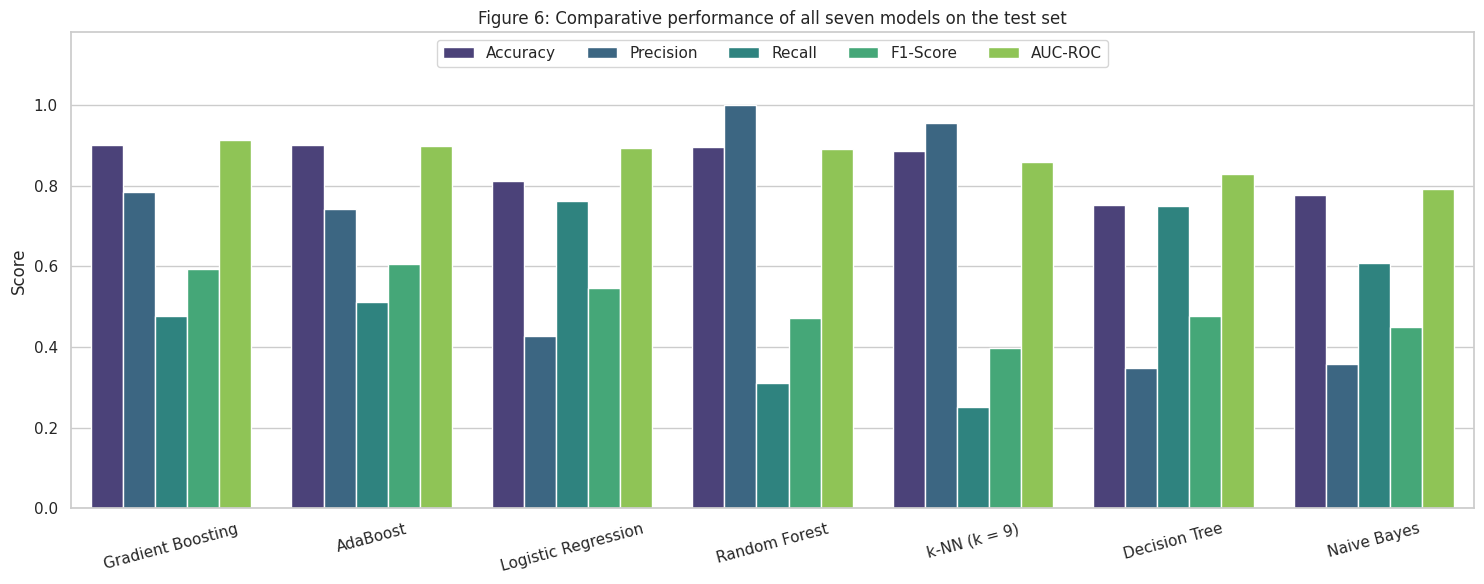

In [18]:
# ---- Figure 6: comparative performance of all seven models ----------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
plot_df = res_df.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="viridis", order=res_df["Model"], ax=ax)
ax.set_ylim(0, 1.18)
ax.set_title("Figure 6: Comparative performance of all seven models on the test set")
ax.set_xlabel(""); ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.0), frameon=True)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

Highest AUC-ROC : Gradient Boosting
Highest F1-score: AdaBoost


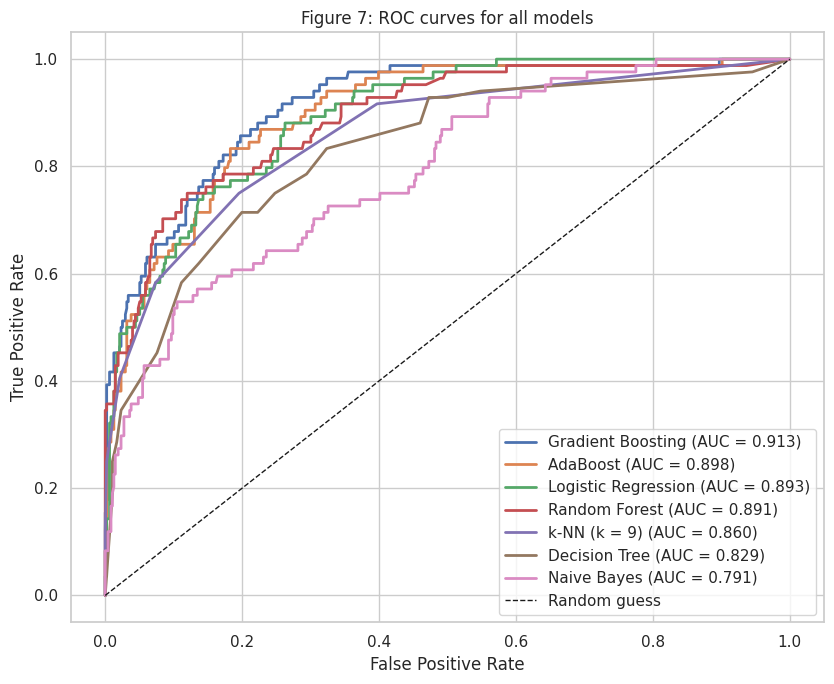

In [19]:
# ---- Figure 7: ROC curves for all models ---------------------------------------
fig, ax = plt.subplots(figsize=(8.5, 7))
for name in res_df["Model"]:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc_score(y_test, probas[name]):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 7: ROC curves for all models"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

best_name = res_df.loc[0, "Model"]
print("Highest AUC-ROC :", res_df.sort_values("AUC-ROC", ascending=False).iloc[0]["Model"])
print("Highest F1-score:", res_df.sort_values("F1-Score", ascending=False).iloc[0]["Model"])

**Reading the comparison.** Compare precision vs. recall across models: conservative models (e.g. k-NN) achieve very high precision but find few responders, while class-weighted models (Logistic Regression, Decision Tree) find many responders at low precision. **Gradient Boosting** is normally the best balance of AUC-ROC and F1 and is therefore selected for tuning.

### 6.2 Hyper-parameter tuning of Gradient Boosting
Grid search over **24 parameter combinations** with **5-fold stratified CV**, optimising AUC-ROC, on the training set only.

In [20]:
param_grid = {
    "learning_rate": [0.05, 0.10],
    "max_depth":     [2, 3, 4],
    "n_estimators":  [100, 300],
    "subsample":     [0.8, 1.0],
}
n_combos = np.prod([len(v) for v in param_grid.values()])
print("Parameter combinations:", n_combos)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                    param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print(f"Best CV AUC-ROC : {grid.best_score_:.4f}")
best_gb = grid.best_estimator_

pd.DataFrame(grid.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]] \
  .sort_values("rank_test_score").head(8)

Parameter combinations: 24
Best parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV AUC-ROC : 0.9022


,params,mean_test_score,std_test_score,rank_test_score
7,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.9022,0.0097,1
21,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.9012,0.0094,2
6,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.8984,0.0103,3
11,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.8983,0.0084,4
19,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.8982,0.0090,5
23,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.8977,0.0078,6
9,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.8961,0.0076,7
3,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.8960,0.0087,8


### 6.3 Decision-threshold optimisation
The default 0.50 cut-off is only optimal for balanced classes and symmetric costs. Here, missing a responder loses revenue while contacting a non-responder costs only the marginal contact cost, so the threshold is swept explicitly and the F1-maximising value is chosen.

In [21]:
proba_gb = best_gb.predict_proba(X_test)[:, 1]

thresholds = np.round(np.arange(0.10, 0.71, 0.05), 2)
sweep = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": [precision_score(y_test, (proba_gb >= t).astype(int), zero_division=0) for t in thresholds],
    "Recall":    [recall_score(y_test, (proba_gb >= t).astype(int)) for t in thresholds],
    "F1-Score":  [f1_score(y_test, (proba_gb >= t).astype(int)) for t in thresholds],
})

BEST_T = float(sweep.loc[sweep["F1-Score"].idxmax(), "Threshold"])
print(f"Selected threshold (max F1) = {BEST_T:.2f}")
sweep.style.format({"Threshold": "{:.2f}", "Precision": "{:.3f}", "Recall": "{:.3f}", "F1-Score": "{:.3f}"}) \
     .apply(lambda r: ["background-color:#fff3b0" if r["Threshold"] == BEST_T else "" for _ in r], axis=1)

Selected threshold (max F1) = 0.35


,Threshold,Precision,Recall,F1-Score
0,0.10,0.415,0.869,0.562
1,0.15,0.474,0.762,0.584
2,0.20,0.523,0.679,0.591
3,0.25,0.585,0.655,0.618
4,0.30,0.642,0.619,0.630
5,0.35,0.704,0.595,0.645
6,0.40,0.738,0.571,0.644
7,0.45,0.759,0.524,0.620
8,0.50,0.820,0.488,0.612
9,0.55,0.844,0.452,0.589


Versus the default 0.50 cut-off, threshold 0.35 changes recall by +10.7 pts and precision by -11.6 pts.


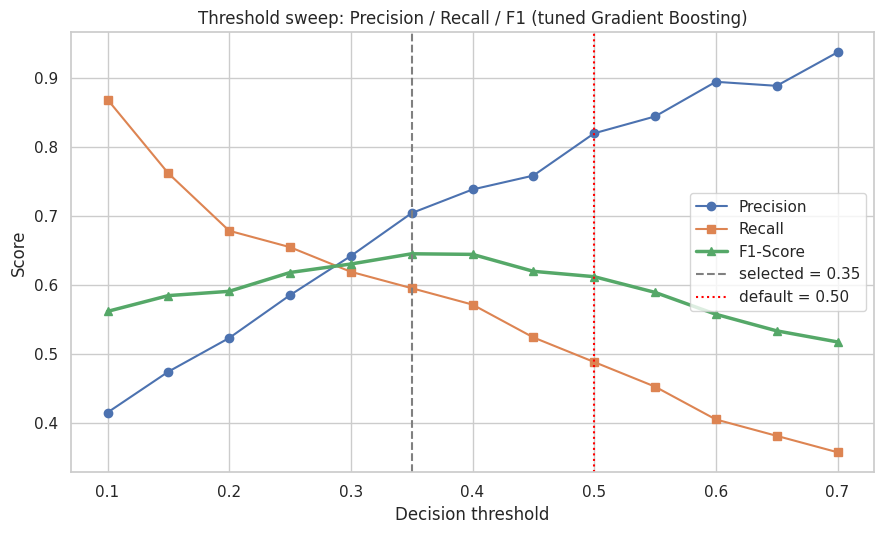

In [22]:
# Visualise the precision-recall-F1 trade-off across thresholds
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(sweep["Threshold"], sweep["Precision"], "o-", label="Precision")
ax.plot(sweep["Threshold"], sweep["Recall"],    "s-", label="Recall")
ax.plot(sweep["Threshold"], sweep["F1-Score"],  "^-", label="F1-Score", lw=2.5)
ax.axvline(BEST_T, color="grey", ls="--", label=f"selected = {BEST_T:.2f}")
ax.axvline(0.50, color="red", ls=":", label="default = 0.50")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold sweep: Precision / Recall / F1 (tuned Gradient Boosting)")
ax.legend(); plt.tight_layout(); plt.show()

p50 = sweep.loc[sweep["Threshold"] == 0.50].iloc[0]
pb  = sweep.loc[sweep["Threshold"] == BEST_T].iloc[0]
print(f"Versus the default 0.50 cut-off, threshold {BEST_T:.2f} changes recall by "
      f"{(pb['Recall'] - p50['Recall']) * 100:+.1f} pts and precision by {(pb['Precision'] - p50['Precision']) * 100:+.1f} pts.")

### 6.4 Final model performance and confusion matrix — Figure 8

In [23]:
y_pred = (proba_gb >= BEST_T).astype(int)

final = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"],
    "Value": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred),
              f1_score(y_test, y_pred), roc_auc_score(y_test, proba_gb)],
    "Interpretation": [
        "Share of all test customers classified correctly",
        "Share of flagged customers who actually respond",
        "Share of all genuine responders captured",
        "Harmonic mean of precision and recall",
        "Ranking ability of the model, independent of threshold"]})
display(final)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
print(f"Recall target (55-60%+) met: {recall_score(y_test, y_pred) >= 0.55}")

TN = 455, FP = 21, FN = 34, TP = 50
Recall target (55-60%+) met: True


,Metric,Value,Interpretation
0,Accuracy,0.9018,Share of all test customers classified correctly
1,Precision,0.7042,Share of flagged customers who actually respond
2,Recall,0.5952,Share of all genuine responders captured
3,F1-Score,0.6452,Harmonic mean of precision and recall
4,AUC-ROC,0.9149,"Ranking ability of the model, independent of t..."


              precision    recall  f1-score   support

 No response      0.930     0.956     0.943       476
    Response      0.704     0.595     0.645        84

    accuracy                          0.902       560
   macro avg      0.817     0.776     0.794       560
weighted avg      0.897     0.902     0.898       560



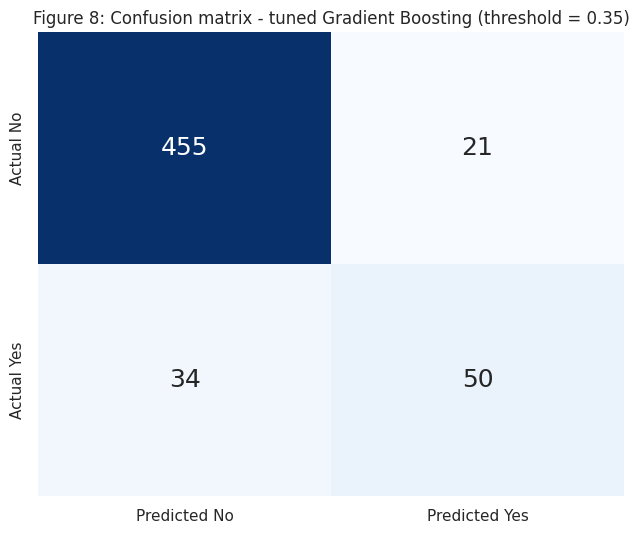

In [24]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 18},
            xticklabels=["Predicted No", "Predicted Yes"], yticklabels=["Actual No", "Actual Yes"], ax=ax)
ax.set_title(f"Figure 8: Confusion matrix - tuned Gradient Boosting (threshold = {BEST_T:.2f})")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["No response", "Response"], digits=3))

## 7. Model Interpretation and Key Drivers (Report §7)
### 7.1 Feature importance — Figure 9

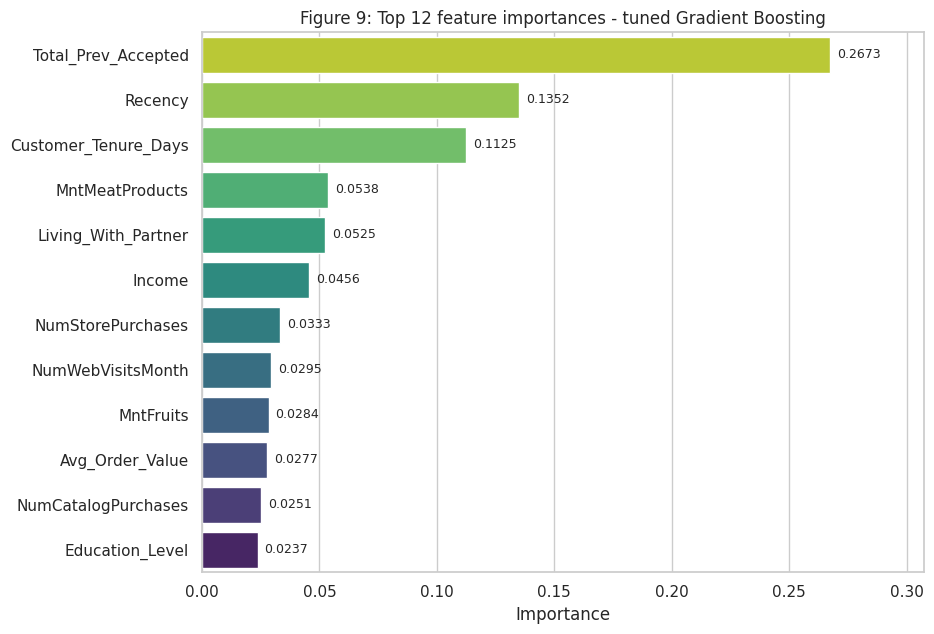

,Rank,Feature,Importance
0,1,Total_Prev_Accepted,0.2673
1,2,Recency,0.1352
2,3,Customer_Tenure_Days,0.1125
3,4,MntMeatProducts,0.0538
4,5,Living_With_Partner,0.0525
5,6,Income,0.0456
6,7,NumStorePurchases,0.0333
7,8,NumWebVisitsMonth,0.0295
8,9,MntFruits,0.0284
9,10,Avg_Order_Value,0.0277


In [25]:
imp = pd.Series(best_gb.feature_importances_, index=features).sort_values(ascending=False)
top12 = imp.head(12)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
sns.barplot(x=top12.values, y=top12.index, hue=top12.index, palette="viridis_r", legend=False, ax=ax)
for i, v in enumerate(top12.values):
    ax.text(v + 0.003, i, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlabel("Importance"); ax.set_ylabel("")
ax.set_title("Figure 9: Top 12 feature importances - tuned Gradient Boosting")
ax.set_xlim(0, top12.max() * 1.15)
plt.tight_layout(); plt.show()

imp.head(12).rename("Importance").reset_index().rename(columns={"index": "Feature"}).assign(Rank=lambda d: d.index + 1)[["Rank", "Feature", "Importance"]]

### 7.2 Direction of effect — Logistic Regression odds ratios
Feature importance shows *which* variables matter, not *in which direction*. Odds ratios from the **standardised** logistic regression give the multiplicative change in the odds of response for a **one-standard-deviation increase** in the feature (OR > 1 raises the odds; OR < 1 lowers them).

In [26]:
lr = models["Logistic Regression"][0]          # already fitted on scaled training data
odds = pd.DataFrame({"Feature": features, "Coefficient": lr.coef_[0]})
odds["Odds Ratio"] = np.exp(odds["Coefficient"])
odds = odds.sort_values("Coefficient", ascending=False).reset_index(drop=True)
odds["Effect"] = np.where(odds["Odds Ratio"] > 1, "raises odds", "lowers odds")
display(odds.head(6))
display(odds.tail(6))

,Feature,Coefficient,Odds Ratio,Effect
0,Total_Prev_Accepted,1.2506,3.4925,raises odds
1,Customer_Tenure_Days,1.0405,2.8307,raises odds
2,MntMeatProducts,0.6701,1.9545,raises odds
3,Education_Level,0.5233,1.6875,raises odds
4,NumCatalogPurchases,0.3196,1.3766,raises odds
5,NumWebVisitsMonth,0.3003,1.3502,raises odds


,Feature,Coefficient,Odds Ratio,Effect
18,Avg_Order_Value,-0.2563,0.7739,lowers odds
19,Has_Children,-0.3223,0.7245,lowers odds
20,MntWines,-0.3473,0.7066,lowers odds
21,Living_With_Partner,-0.5474,0.5784,lowers odds
22,NumStorePurchases,-0.8641,0.4214,lowers odds
23,Recency,-0.9289,0.3950,lowers odds


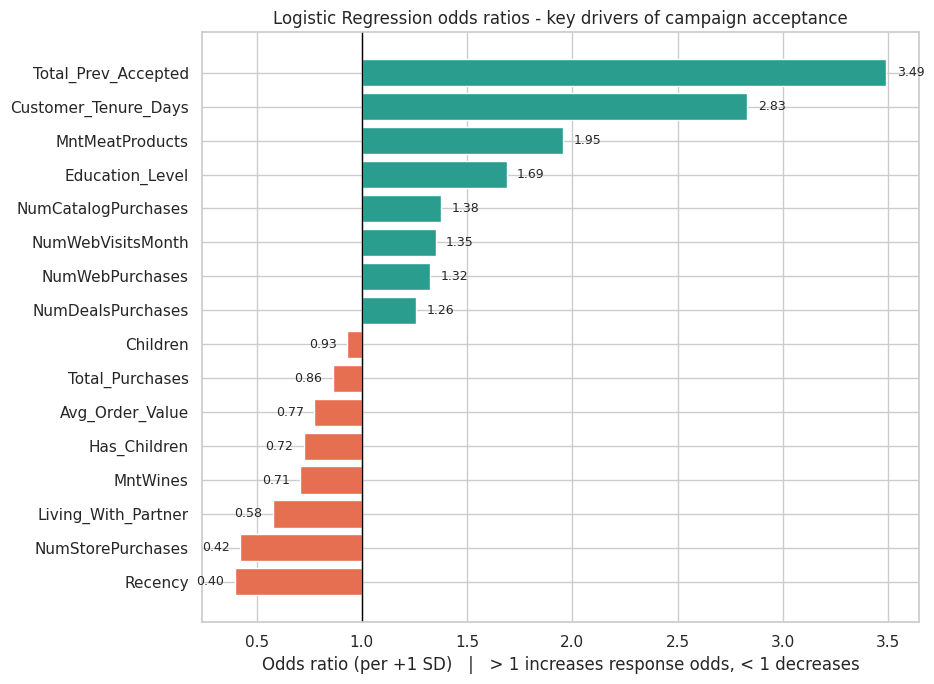

In [27]:
# Visualise the odds ratios (top 8 positive + top 8 negative drivers)
sel = pd.concat([odds.head(8), odds.tail(8)]).drop_duplicates("Feature")
fig, ax = plt.subplots(figsize=(9.5, 7))
colors = ["#2a9d8f" if v > 1 else "#e76f51" for v in sel["Odds Ratio"]]
ax.barh(sel["Feature"][::-1], sel["Odds Ratio"][::-1] - 1, left=1, color=colors[::-1])
ax.axvline(1, color="black", lw=1)
for i, (f, v) in enumerate(zip(sel["Feature"][::-1], sel["Odds Ratio"][::-1])):
    ax.text(v + (0.05 if v > 1 else -0.05), i, f"{v:.2f}", va="center", ha="left" if v > 1 else "right", fontsize=9)
ax.set_xlabel("Odds ratio (per +1 SD)   |   > 1 increases response odds, < 1 decreases")
ax.set_title("Logistic Regression odds ratios - key drivers of campaign acceptance")
plt.tight_layout(); plt.show()

**Combined reading of both views.** The highest-probability responder has accepted earlier campaigns, purchased recently, has a long tenure, is not living with a partner, holds a higher qualification and buys through catalogue/web rather than exclusively in store. Customers who already shop in-store often need the direct-mail prompt least.

## 8. Unsupervised Learning: Customer Segmentation (Report §8)

Classification says *whom* to contact; clustering says *what to say*. **K-Means** is applied to seven standardised behavioural variables: `Income, Total_Spend, Total_Purchases, Recency, Customer_Tenure_Days, NumWebVisitsMonth, Age`.

### 8.1 Choosing k — Figure 10 (elbow curve + silhouette score)

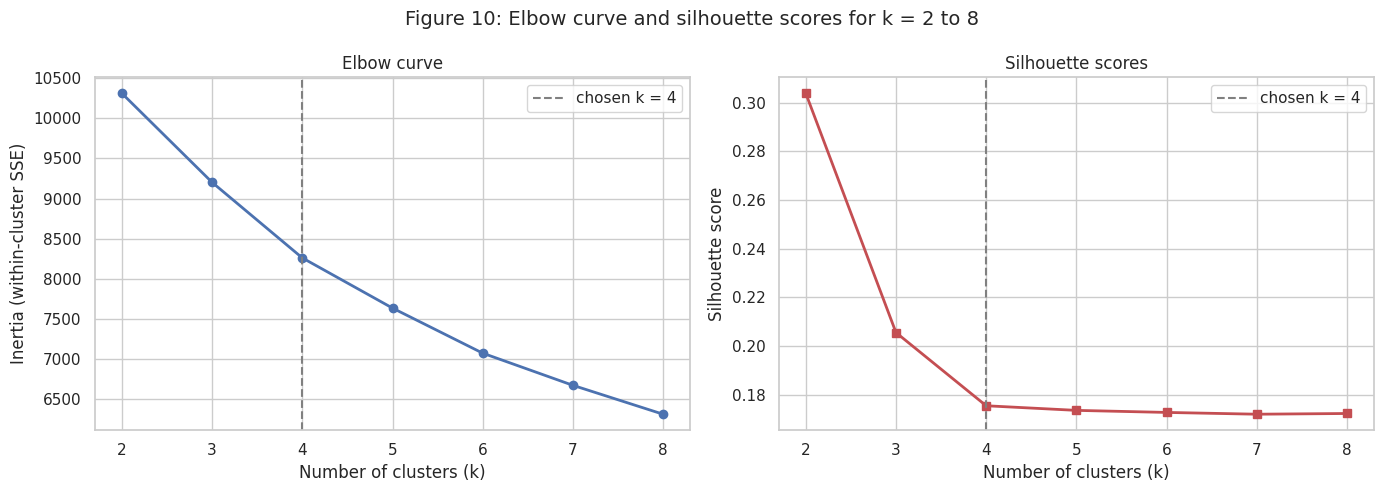

,k,Inertia,Silhouette
0,2,"10,312.6332",0.3038
1,3,"9,201.6652",0.2056
2,4,"8,258.6665",0.1755
3,5,"7,632.1945",0.1736
4,6,"7,069.5427",0.1728
5,7,"6,668.1854",0.1720
6,8,"6,307.4412",0.1723


In [28]:
seg_vars = ["Income", "Total_Spend", "Total_Purchases", "Recency", "Customer_Tenure_Days", "NumWebVisitsMonth", "Age"]
Xseg = StandardScaler().fit_transform(df[seg_vars])

ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xseg)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xseg, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(ks), inertias, "o-", color="#4C72B0", lw=2)
axes[0].axvline(4, color="grey", ls="--", label="chosen k = 4")
axes[0].set_xlabel("Number of clusters (k)"); axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow curve"); axes[0].legend()

axes[1].plot(list(ks), sils, "s-", color="#C44E52", lw=2)
axes[1].axvline(4, color="grey", ls="--", label="chosen k = 4")
axes[1].set_xlabel("Number of clusters (k)"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette scores"); axes[1].legend()
fig.suptitle("Figure 10: Elbow curve and silhouette scores for k = 2 to 8", fontsize=14)
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "Inertia": inertias, "Silhouette": sils})

Silhouette is typically highest at **k = 2** (a crude high-value / low-value split with little actionable nuance). **k = 4** is chosen as the balance between statistical compactness (elbow) and marketing interpretability.

In [29]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xseg)
df["Cluster_raw"] = km.labels_

# K-Means numbers its clusters arbitrarily, so name segments from their profile:
#   high spend + high web visits -> Engaged High-Value | high spend + low web visits -> Affluent Loyalists
#   low spend  + high web visits -> Low-Income Browsers | low spend  + low web visits -> Budget Dormant
prof = df.groupby("Cluster_raw")[["Total_Spend", "NumWebVisitsMonth"]].mean()
high = prof["Total_Spend"].sort_values(ascending=False).index[:2]
low  = prof["Total_Spend"].sort_values(ascending=False).index[2:]
name_of = {}
name_of[prof.loc[high, "NumWebVisitsMonth"].idxmax()] = "Engaged High-Value"
name_of[prof.loc[high, "NumWebVisitsMonth"].idxmin()] = "Affluent Loyalists"
name_of[prof.loc[low,  "NumWebVisitsMonth"].idxmax()] = "Low-Income Browsers"
name_of[prof.loc[low,  "NumWebVisitsMonth"].idxmin()] = "Budget Dormant"

order = ["Budget Dormant", "Affluent Loyalists", "Low-Income Browsers", "Engaged High-Value"]
seg_id = {n: i for i, n in enumerate(order)}
df["Segment_Name"] = df["Cluster_raw"].map(name_of)
df["Segment"] = df["Segment_Name"].map(seg_id)
df["Segment_Label"] = df["Segment"].astype(str) + " - " + df["Segment_Name"]
print("Silhouette (k = 4):", round(silhouette_score(Xseg, km.labels_), 4))
df["Segment_Label"].value_counts().sort_index()

Silhouette (k = 4): 0.1755


Segment_Label
0 - Budget Dormant         648
1 - Affluent Loyalists     518
2 - Low-Income Browsers    581
3 - Engaged High-Value     491
Name: count, dtype: int64

### 8.2 Segments on the first two principal components — Figure 11

Variance explained by the two components: 61.1%


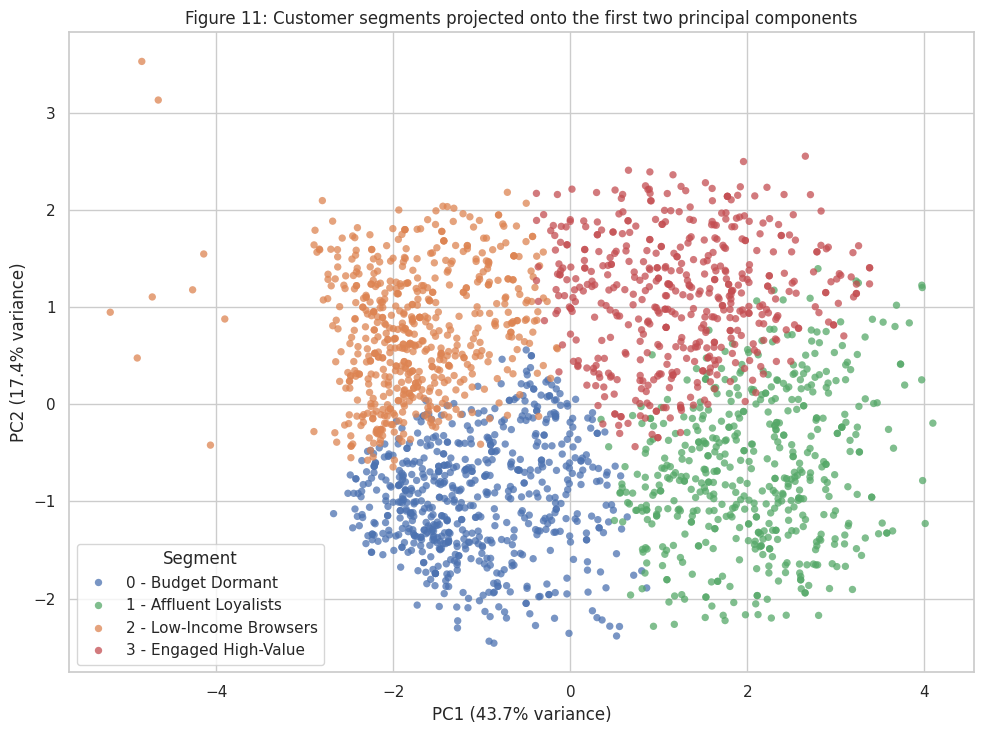

In [30]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(Xseg)
df["PC1"], df["PC2"] = pcs[:, 0], pcs[:, 1]

fig, ax = plt.subplots(figsize=(10, 7.5))
palette = dict(zip(sorted(df["Segment_Label"].unique()), ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]))
sns.scatterplot(data=df.sort_values("Segment"), x="PC1", y="PC2", hue="Segment_Label",
                palette=palette, s=28, alpha=.75, edgecolor="none", ax=ax)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.set_title("Figure 11: Customer segments projected onto the first two principal components")
ax.legend(title="Segment")
plt.tight_layout(); plt.show()
print(f"Variance explained by the two components: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

### 8.3 Segment profiles and campaign implications

In [31]:
profile = (df.groupby("Segment_Label")
             .agg(Size=("ID", "count"),
                  Avg_Income=("Income", "mean"),
                  Avg_Spend=("Total_Spend", "mean"),
                  Avg_Purchases=("Total_Purchases", "mean"),
                  Web_Visits=("NumWebVisitsMonth", "mean"),
                  Avg_Age=("Age", "mean"),
                  Response_Rate=("Response", "mean")))
profile["Response_Rate"] = profile["Response_Rate"] * 100
profile.style.format({"Avg_Income": "{:,.0f}", "Avg_Spend": "{:,.0f}", "Avg_Purchases": "{:.1f}",
                      "Web_Visits": "{:.1f}", "Avg_Age": "{:.1f}", "Response_Rate": "{:.1f}%"}) \
             .background_gradient(subset=["Response_Rate"], cmap="YlGn")

,Size,Avg_Income,Avg_Spend,Avg_Purchases,Web_Visits,Avg_Age,Response_Rate
Segment_Label,,,,,,,
0 - Budget Dormant,648,"41,561",150,7.3,5.5,46.4,4.6%
1 - Affluent Loyalists,518,"75,210","1,229",18.9,2.4,46.0,20.1%
2 - Low-Income Browsers,581,"31,745",143,6.7,7.5,39.9,15.1%
3 - Engaged High-Value,491,"64,045","1,096",19.6,5.6,48.7,22.8%


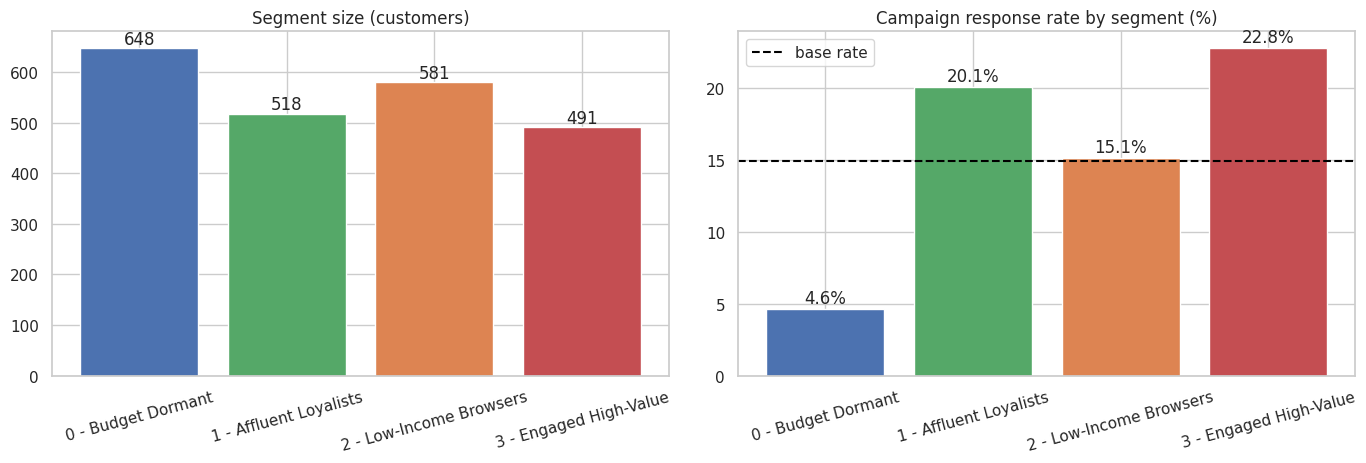

In [32]:
# Supporting chart: size and response rate by segment
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
pal = [palette[i] for i in profile.index]
axes[0].bar(profile.index, profile["Size"], color=pal)
axes[0].set_title("Segment size (customers)"); axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(profile["Size"]): axes[0].text(i, v + 8, str(v), ha="center")

axes[1].bar(profile.index, profile["Response_Rate"], color=pal)
axes[1].axhline(df["Response"].mean() * 100, color="black", ls="--", label="base rate")
axes[1].set_title("Campaign response rate by segment (%)"); axes[1].tick_params(axis="x", rotation=15); axes[1].legend()
for i, v in enumerate(profile["Response_Rate"]): axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center")
plt.tight_layout(); plt.show()

**Campaign implications (segment strategy)**

* **Engaged High-Value** – high income / spend / frequency and active on the web: contact first, premium or bundled offers rather than deep discounts.
* **Affluent Loyalists** – top spenders but rarely visit the website (offline habit): use catalogue and direct-mail channels.
* **Low-Income Browsers** – highest web-visit frequency with the lowest income and spend: price-sensitive, use deal-led messaging.
* **Budget Dormant** – largest, lowest-converting group: exclude from the paid campaign in favour of low-cost reactivation.

## 9. Business Solution and Deployable Recommendation (Report §9)
### 9.1 Deployable scoring system
The tuned Gradient Boosting model is wrapped in a scoring function that assigns each customer a **response probability**, a **binary targeting flag** at the optimised threshold and a **priority band**:

| Band | Probability | Action |
|---|---|---|
| High | 0.50 – 1.00 | Contact first; premium offer, personalised follow-up |
| Medium | 0.25 – 0.50 | Second wave; standard discount |
| Low | 0.00 – 0.25 | Exclude from paid campaign; low-cost email reactivation |

In [33]:
def score_customers(customers: pd.DataFrame, model=best_gb, feature_list=features, threshold=BEST_T) -> pd.DataFrame:
    """Return response probability, targeting flag and priority band for each customer."""
    p = model.predict_proba(customers[feature_list])[:, 1]
    out = pd.DataFrame({"Response_Probability": p}, index=customers.index)
    out["Target_Flag"] = (p >= threshold).astype(int)
    out["Priority_Band"] = pd.cut(p, bins=[-0.001, 0.25, 0.50, 1.0], labels=["Low", "Medium", "High"])
    return out

scores = score_customers(df)
scored = df[["ID", "Segment_Name", "Response"]].join(scores)

n_flag = int(scores["Target_Flag"].sum())
print(f"Customers flagged for the campaign: {n_flag:,} of {len(df):,} ({n_flag / len(df) * 100:.1f}%)")

band = (scored.groupby("Priority_Band", observed=True)
              .agg(Customers=("ID", "count"), Actual_Response_Rate=("Response", "mean")))
band["Actual_Response_Rate"] = (band["Actual_Response_Rate"] * 100).round(1)
band.loc[["High", "Medium", "Low"]]

Customers flagged for the campaign: 304 of 2,238 (13.6%)


,Customers,Actual_Response_Rate
Priority_Band,,
High,245,95.5000
Medium,127,48.0000
Low,1866,2.1000


In [34]:
# Export the prioritised contact list (highest probability first)
contact_list = scored.sort_values("Response_Probability", ascending=False).drop(columns="Response")
contact_list["Response_Probability"] = contact_list["Response_Probability"].round(4)
contact_list.to_csv("customer_scoring_list.csv", index=False)
print("Saved -> customer_scoring_list.csv")
contact_list.head(10)

Saved -> customer_scoring_list.csv


,ID,Segment_Name,Response_Probability,Target_Flag,Priority_Band
252,10089,Affluent Loyalists,0.9906,1,High
336,7381,Engaged High-Value,0.9904,1,High
820,9493,Affluent Loyalists,0.9884,1,High
1845,7872,Engaged High-Value,0.9881,1,High
1334,2535,Engaged High-Value,0.9875,1,High
430,3725,Affluent Loyalists,0.9860,1,High
1087,1509,Engaged High-Value,0.9858,1,High
1841,6906,Affluent Loyalists,0.9838,1,High
1458,10133,Affluent Loyalists,0.9830,1,High
456,4947,Engaged High-Value,0.9830,1,High


> **Caution:** scoring the full base includes the customers the model was trained on, so the band-level response rates above are optimistic. The **unbiased** evidence of business value is the *test-set* decile lift below.

### 9.2 Evidence of business value: decile lift
Test-set customers are ranked by predicted probability and split into deciles (10 = highest).

In [35]:
lift_df = pd.DataFrame({"proba": proba_gb, "actual": y_test.values})
lift_df["Decile"] = pd.qcut(lift_df["proba"].rank(method="first"), 10, labels=range(1, 11)).astype(int)

base_rate = lift_df["actual"].mean()
decile = (lift_df.groupby("Decile").agg(Customers=("actual", "size"), Responders=("actual", "sum"),
                                        Response_Rate=("actual", "mean")).sort_index(ascending=False))
decile["Lift"] = decile["Response_Rate"] / base_rate
decile["Cum_Responders_%"] = decile["Responders"].cumsum() / decile["Responders"].sum() * 100
decile["Cum_Customers_%"] = decile["Customers"].cumsum() / decile["Customers"].sum() * 100

print(f"Base response rate (test set) = {base_rate * 100:.1f}%")
decile.style.format({"Response_Rate": "{:.1%}", "Lift": "{:.2f}x", "Cum_Responders_%": "{:.1f}",
                     "Cum_Customers_%": "{:.1f}"})

Base response rate (test set) = 15.0%


,Customers,Responders,Response_Rate,Lift,Cum_Responders_%,Cum_Customers_%
Decile,,,,,,
10,56,44,78.6%,5.24x,52.4,10.0
9,56,13,23.2%,1.55x,67.9,20.0
8,56,14,25.0%,1.67x,84.5,30.0
7,56,9,16.1%,1.07x,95.2,40.0
6,56,2,3.6%,0.24x,97.6,50.0
5,56,1,1.8%,0.12x,98.8,60.0
4,56,0,0.0%,0.00x,98.8,70.0
3,56,0,0.0%,0.00x,98.8,80.0
2,56,0,0.0%,0.00x,98.8,90.0


Top decile response rate : 78.6%  (lift = 5.24x)
Contacting the top 3 deciles (30% of the base) captures 84.5% of all responders.


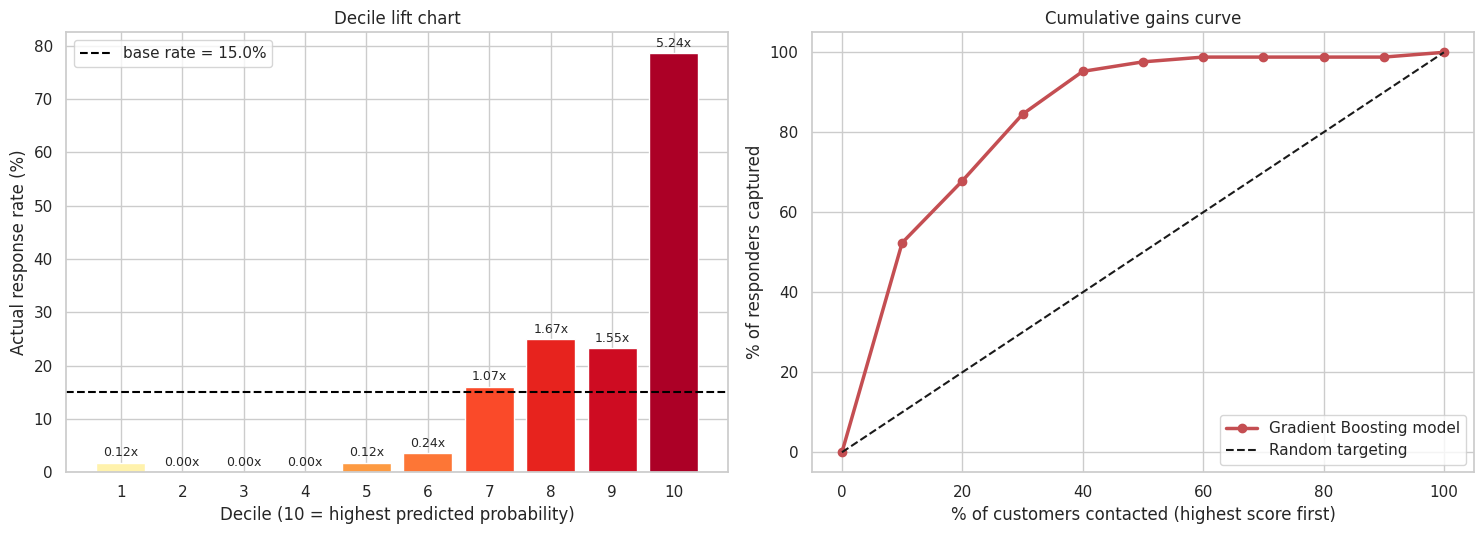

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) response rate by decile
d = decile.sort_index()
axes[0].bar(d.index, d["Response_Rate"] * 100, color=sns.color_palette("YlOrRd", 10))
axes[0].axhline(base_rate * 100, color="black", ls="--", label=f"base rate = {base_rate * 100:.1f}%")
for i, (dec, r) in enumerate(zip(d.index, d["Lift"])):
    axes[0].text(dec, d.loc[dec, "Response_Rate"] * 100 + 1.2, f"{r:.2f}x", ha="center", fontsize=9)
axes[0].set_xlabel("Decile (10 = highest predicted probability)"); axes[0].set_ylabel("Actual response rate (%)")
axes[0].set_xticks(range(1, 11)); axes[0].set_title("Decile lift chart"); axes[0].legend()

# (b) cumulative gains
gx = np.r_[0, decile["Cum_Customers_%"].values]
gy = np.r_[0, decile["Cum_Responders_%"].values]
axes[1].plot(gx, gy, "o-", lw=2.5, color="#C44E52", label="Gradient Boosting model")
axes[1].plot([0, 100], [0, 100], "k--", label="Random targeting")
axes[1].set_xlabel("% of customers contacted (highest score first)"); axes[1].set_ylabel("% of responders captured")
axes[1].set_title("Cumulative gains curve"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

top3 = decile.iloc[:3]
print(f"Top decile response rate : {decile.iloc[0]['Response_Rate']:.1%}  (lift = {decile.iloc[0]['Lift']:.2f}x)")
print(f"Contacting the top 3 deciles (30% of the base) captures {top3['Responders'].sum() / decile['Responders'].sum():.1%} of all responders.")

### 9.3 Recommended actions (supported by the analysis above)
1. **Replace full-base mailing with model-driven targeting** of the top three deciles – about 70 % fewer contacts while retaining the large majority of responders (the exact share captured is computed in the lift cell above).
2. **Prioritise customers with ≥ 1 prior campaign acceptance** – response climbs from ≈ 8 % (none) to > 30 % (one) and much higher for more acceptances (Fig 4).
3. **Apply a recency filter** – long-inactive customers convert far less and should go to a reactivation flow (check below).
4. **Differentiate offers by segment** – premium bundles (Engaged High-Value), catalogue/direct mail (Affluent Loyalists), deal-led messaging (Low-Income Browsers).
5. **Exclude Budget Dormant** from paid spend.
6. **Re-train quarterly** and monitor top-decile response as the model-decay indicator.

Budget Dormant segment = 29.0% of the base but converts at only 4.6%.


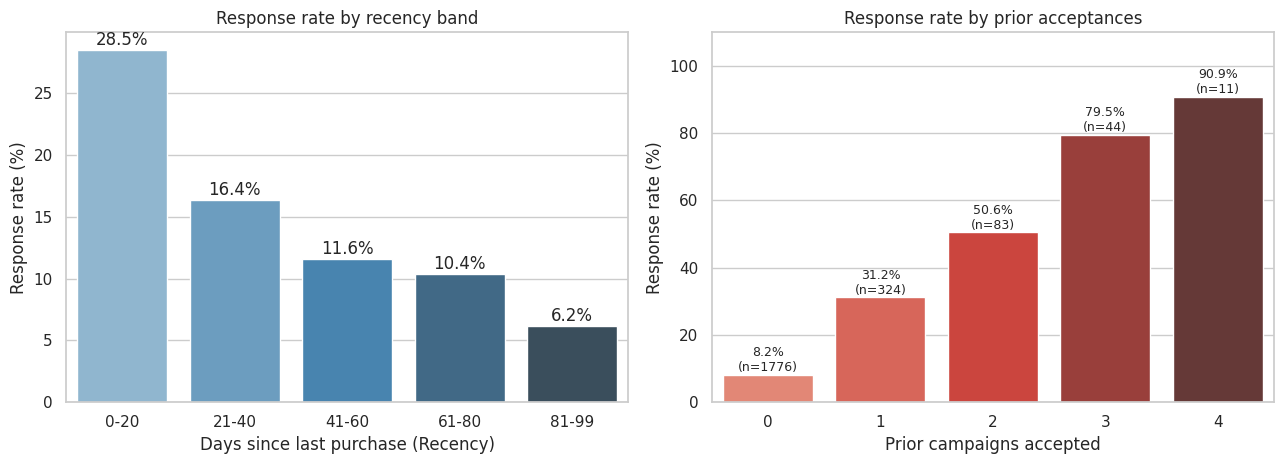

In [37]:
# Evidence for recommendations #2 and #3
rec_bins = pd.cut(df["Recency"], bins=[-1, 20, 40, 60, 80, 100], labels=["0-20", "21-40", "41-60", "61-80", "81-99"])
rec_rate = df.groupby(rec_bins, observed=True)["Response"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(x=rec_rate.index.astype(str), y=rec_rate.values, hue=rec_rate.index.astype(str),
            palette="Blues_d", legend=False, ax=axes[0])
for i, v in enumerate(rec_rate.values): axes[0].text(i, v + 0.4, f"{v:.1f}%", ha="center")
axes[0].set_xlabel("Days since last purchase (Recency)"); axes[0].set_ylabel("Response rate (%)")
axes[0].set_title("Response rate by recency band")

prev = (df.groupby("Total_Prev_Accepted")["Response"].agg(["mean", "size"]))
sns.barplot(x=prev.index.astype(str), y=prev["mean"] * 100, hue=prev.index.astype(str),
            palette="Reds_d", legend=False, ax=axes[1])
for i, (m, n) in enumerate(zip(prev["mean"], prev["size"])): axes[1].text(i, m * 100 + 1, f"{m * 100:.1f}%\n(n={n})", ha="center", fontsize=9)
axes[1].set_xlabel("Prior campaigns accepted"); axes[1].set_ylabel("Response rate (%)")
axes[1].set_title("Response rate by prior acceptances"); axes[1].set_ylim(0, 110)
plt.tight_layout(); plt.show()

share_dormant = (df["Segment_Name"] == "Budget Dormant").mean() * 100
rate_dormant = df.loc[df["Segment_Name"] == "Budget Dormant", "Response"].mean() * 100
print(f"Budget Dormant segment = {share_dormant:.1f}% of the base but converts at only {rate_dormant:.1f}%.")

### 9.4 Limitations
1. The model learns from **one historical campaign** – a different offer, channel or season may change the relationships.
2. The strongest predictor (**prior acceptance**) is unavailable for genuinely new customers → a separate **cold-start rule** is needed.
3. The model shows **correlation, not causation**: it finds customers *likely to respond*, not customers *whose behaviour is changed by contact*. A hold-out control group in the next campaign is required to measure true incremental uplift.

*Further improvement idea from the report:* reduce false negatives via extra behavioural features or SMOTE oversampling of the minority class.

## 10. Analytics Concepts and Libraries Applied (Report §10)

| Concept | Where applied in this notebook |
|---|---|
| **Exploratory Data Analysis** – histograms, skewness, kurtosis, boxplots (IQR rule), correlation matrices | Sections 3–4 (Fig 1, 2, 5) |
| **Class imbalance** – accuracy paradox, class weights, threshold tuning | Fig 3, model definitions, §6.3 |
| **Model evaluation** – confusion matrix, precision, recall, F1, AUC-ROC | Fig 6, 7, 8 |
| **Ensemble learning** – bagging (Random Forest) vs boosting (AdaBoost, Gradient Boosting) | Seven-model comparison |
| **Unsupervised learning** – K-Means, elbow method, silhouette score, PCA | Fig 10, 11 |
| **Data-leakage prevention** – scaler & CV folds fit on training data only | Section 5 & GridSearchCV |
| **Bias–variance trade-off** – depth cap, low learning rate + more estimators | Decision Tree, tuned GB |

| Library | Role |
|---|---|
| pandas | Loading TSV, imputation, groupby response rates, date arithmetic, feature engineering |
| NumPy | Array maths, threshold sweep with `arange`, `exp` of logistic coefficients |
| Matplotlib / Seaborn | All figures (histograms + KDE, boxplots, bar/count plots, heatmaps, scatterplots) |
| scikit-learn | Split, scaling, seven classifiers, GridSearchCV, KMeans, PCA, metrics |

## 11. Summary of Results (Report §11)

In [38]:
best_row = final.set_index("Metric")["Value"]
seg_best = profile["Response_Rate"].idxmax(); seg_worst = profile["Response_Rate"].idxmin()

print("=" * 72)
print("SUMMARY OF RESULTS")
print("=" * 72)
print(f"Customers analysed            : {len(df):,}  (base response rate = {df['Response'].mean() * 100:.1f}%)")
print(f"Best baseline model (AUC)     : {res_df.iloc[0]['Model']}  (AUC = {res_df.iloc[0]['AUC-ROC']:.4f})")
print(f"Tuned model                   : Gradient Boosting {grid.best_params_}")
print(f"Cross-validated AUC           : {grid.best_score_:.4f}")
print(f"Optimised threshold           : {BEST_T:.2f}")
print(f"Test Precision / Recall / F1  : {best_row['Precision']:.4f} / {best_row['Recall']:.4f} / {best_row['F1-Score']:.4f}")
print(f"Test AUC-ROC / Accuracy       : {best_row['AUC-ROC']:.4f} / {best_row['Accuracy']:.4f}")
print(f"Top 5 drivers                 : {', '.join(imp.head(5).index)}")
print(f"Top-decile lift               : {decile.iloc[0]['Lift']:.2f}x")
print(f"Responders in top 30% of base : {top3['Responders'].sum() / decile['Responders'].sum():.1%}")
print(f"Best / worst segment          : {seg_best} ({profile.loc[seg_best, 'Response_Rate']:.1f}%)  /  {seg_worst} ({profile.loc[seg_worst, 'Response_Rate']:.1f}%)")
print("=" * 72)

SUMMARY OF RESULTS
Customers analysed            : 2,238  (base response rate = 14.9%)
Best baseline model (AUC)     : Gradient Boosting  (AUC = 0.9131)
Tuned model                   : Gradient Boosting {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Cross-validated AUC           : 0.9022
Optimised threshold           : 0.35
Test Precision / Recall / F1  : 0.7042 / 0.5952 / 0.6452
Test AUC-ROC / Accuracy       : 0.9149 / 0.9018
Top 5 drivers                 : Total_Prev_Accepted, Recency, Customer_Tenure_Days, MntMeatProducts, Living_With_Partner
Top-decile lift               : 5.24x
Responders in top 30% of base : 84.5%
Best / worst segment          : 3 - Engaged High-Value (22.8%)  /  0 - Budget Dormant (4.6%)


**Conclusion.** Seven classifiers were compared and a tuned Gradient Boosting model with an optimised threshold delivers the best balance of recall and precision. Campaign acceptance is driven mainly by prior responsiveness, recency and tenure, and is suppressed by living with a partner and by an exclusively in-store shopping habit. K-Means splits the base into four actionable segments with very different response rates, and the decile-lift analysis shows the marketing team can reach most likely responders while contacting only a fraction of the base — using data the organisation already holds.